In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler as mms 
from GA_functions import fitness, select_parents, crossover, mutation, GA_algorithm, GA_algorithm_unnormalized, conc_to_spectra, perform_iteration, set_seed #normalize_and_pca
from tree_search_functions import zeroth_iteration, nth_iteration, plot_fitness, plot_spectra, plot_DLS
from SAXS_model import model, model2
from spectroscopy import obtain_spectra

## Define Emulator

Define the emulator as a function.

In [2]:
def perform_simulations(conc_array, wavelength_1, wavelength_2):
    for i in range(conc_array.shape[0]):
        #Emulator 1: SAXS curve
        spectra_1_row = model(wavelength_1, 10*conc_array[i,0], 3*conc_array[i,1]).reshape(1,-1)
        #Emulator 2: SAXS curve
        spectra_2_row = model2(wavelength_1, 10*conc_array[i,0], 3*conc_array[i,1]).reshape(1,-1) 
        if i == 0:
            spectra_array_1 = spectra_1_row
            spectra_array_2 = spectra_2_row
        else:
            spectra_array_1 = np.vstack((spectra_array_1, spectra_1_row))
            spectra_array_2 = np.vstack((spectra_array_2, spectra_2_row))
    return spectra_array_1, spectra_array_2

### Initialize first iteration of Input parameters and Output parameters

In [3]:
np.random.seed(2)
conc_array = np.random.dirichlet((1, 1), 30)
q1 = np.linspace(1e-1, 1, 81)
q2 = np.linspace(1e-1, 1, 81)
spectra_array_1, spectra_array_2 = perform_simulations(conc_array, q1, q2) 

### Initialize Targets

These are the spectra that are the targets of the optimization. The algorithm will try to find the best input parameters to create a sample that has a spectra closest to the two targets.

In [4]:
desired_spectra_1 = model(q1, 5,2).reshape(1,-1) 
desired_spectra_2 = model2(q2, 2,.5).reshape(1,-1) 

## Zeroth Iteration

These cells initialize the experiment by plotting the fitness score of the initial sample's spectra/ scattering curve compared to the target spectra/ scattering curve. It will also plot all the spectra/ scattering curve.

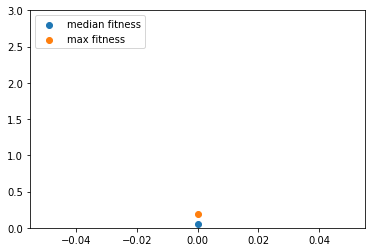

The max fitness is: 0.19426651712834847
The median fitness is: 0.05580912239123177


In [5]:
desired_spectra_1 = desired_spectra_1.reshape(-1,1)
desired_spectra_2 = desired_spectra_2.reshape(-1,1)
loaded_dict = zeroth_iteration(conc_array = conc_array, spectra_array_1 = spectra_array_1, desired_spectra_1 = desired_spectra_1, spectra_array_2 = spectra_array_2, desired_spectra_2 = desired_spectra_2)

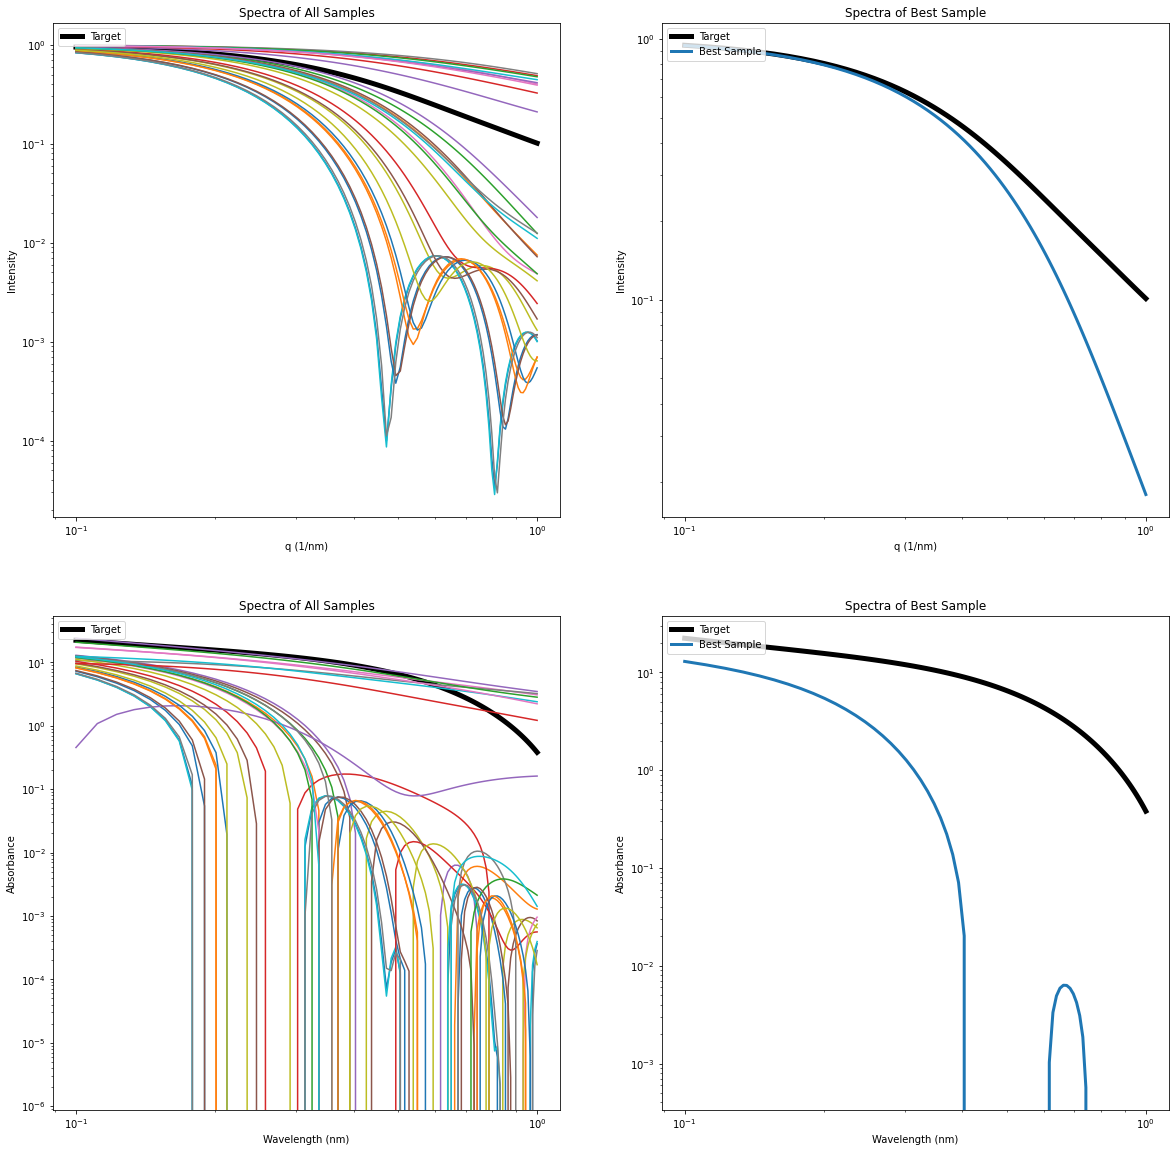

In [6]:
plot_spectra(loaded_dict, wavelength_1 = q1, wavelength_2 = q2, savefig = False)

## Nth Iteration 

Run the cells starting from here all the way to the end of the notebook to perform an additional iteration. A plot of the maximum and median fitness over the iterations will be created and plots of all the sample's spectra/scattering curve compared to the target spectra/scattering curve will be generated.

In [33]:
Iterations = 25 #sample size for GA 
Moves_ahead = 3 #moves ahead that are calculated 
GA_iterations = 8 #times per move that the GA is used 
n_samples = 30 #sample size
seed = 2
loaded_dict = nth_iteration(loaded_dict, seed = seed, Iterations = Iterations, Moves_ahead = Moves_ahead, GA_iterations = GA_iterations, n_samples = n_samples)

The best move has a fitness value of 6.126711487592878
The best move occurs in 2 turns.

The surrogate model has a score of: 0.7554726726984746

[[0.587      0.4419325 ]
 [0.586      0.857     ]
 [0.501      0.72585419]
 [0.494      0.459     ]
 [0.564      0.76      ]
 [0.50371562 0.76406703]
 [0.594      0.775     ]
 [0.411      0.72604922]
 [0.48762447 0.54843199]
 [0.501      0.72838914]
 [0.53096526 0.568     ]
 [0.53208135 0.425     ]
 [0.425      0.555     ]
 [0.594      0.655     ]
 [0.53415047 0.775     ]
 [0.494      0.475     ]
 [0.506      0.655     ]
 [0.502      0.725     ]
 [0.502      0.602     ]
 [0.502      0.765     ]
 [0.37026848 0.402     ]
 [0.757      0.67143545]
 [0.5927704  0.664     ]
 [0.502      0.532     ]
 [0.522      0.68360465]
 [0.581      0.867     ]
 [0.60263069 0.728     ]
 [0.502      0.602     ]
 [0.592      0.861     ]
 [0.505      0.605     ]]


In [34]:
loaded_dict['next_gen_conc'][-1,:] = loaded_dict['best_conc_array'][:-1]
loaded_dict['next_gen_conc'][-2,:] = loaded_dict['best_candidate_array'][-1, 0:-1]

In [35]:
spectra_array_1, spectra_array_2 = perform_simulations(loaded_dict['next_gen_conc'], q1, q2)
loaded_dict['conc_array_actual'] = np.vstack((loaded_dict['conc_array_actual'],loaded_dict['next_gen_conc']))
loaded_dict['spectra_array_actual_1'] = np.vstack((loaded_dict['spectra_array_actual_1'], spectra_array_1))
loaded_dict['spectra_array_actual_2'] = np.vstack((loaded_dict['spectra_array_actual_2'], spectra_array_2))
loaded_dict['spectra_array_1'] = spectra_array_1
loaded_dict['spectra_array_2'] = spectra_array_2

The max fitness is: 1.4402857998576868
The median fitness is: 0.25633591526741073
The best candidate has input parameters of [0.502 0.702]
The best candidate has a fitness value of 3.576577977036832


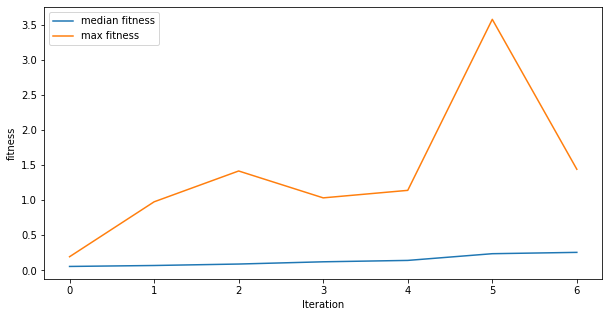

In [36]:
median_fitness_list, max_fitness_list, iteration, best_candidate_array = plot_fitness(loaded_dict, savefig = False)
loaded_dict['best_candidate_array'] = best_candidate_array
loaded_dict['median_fitness_list'] = median_fitness_list
loaded_dict['max_fitness_list'] = max_fitness_list


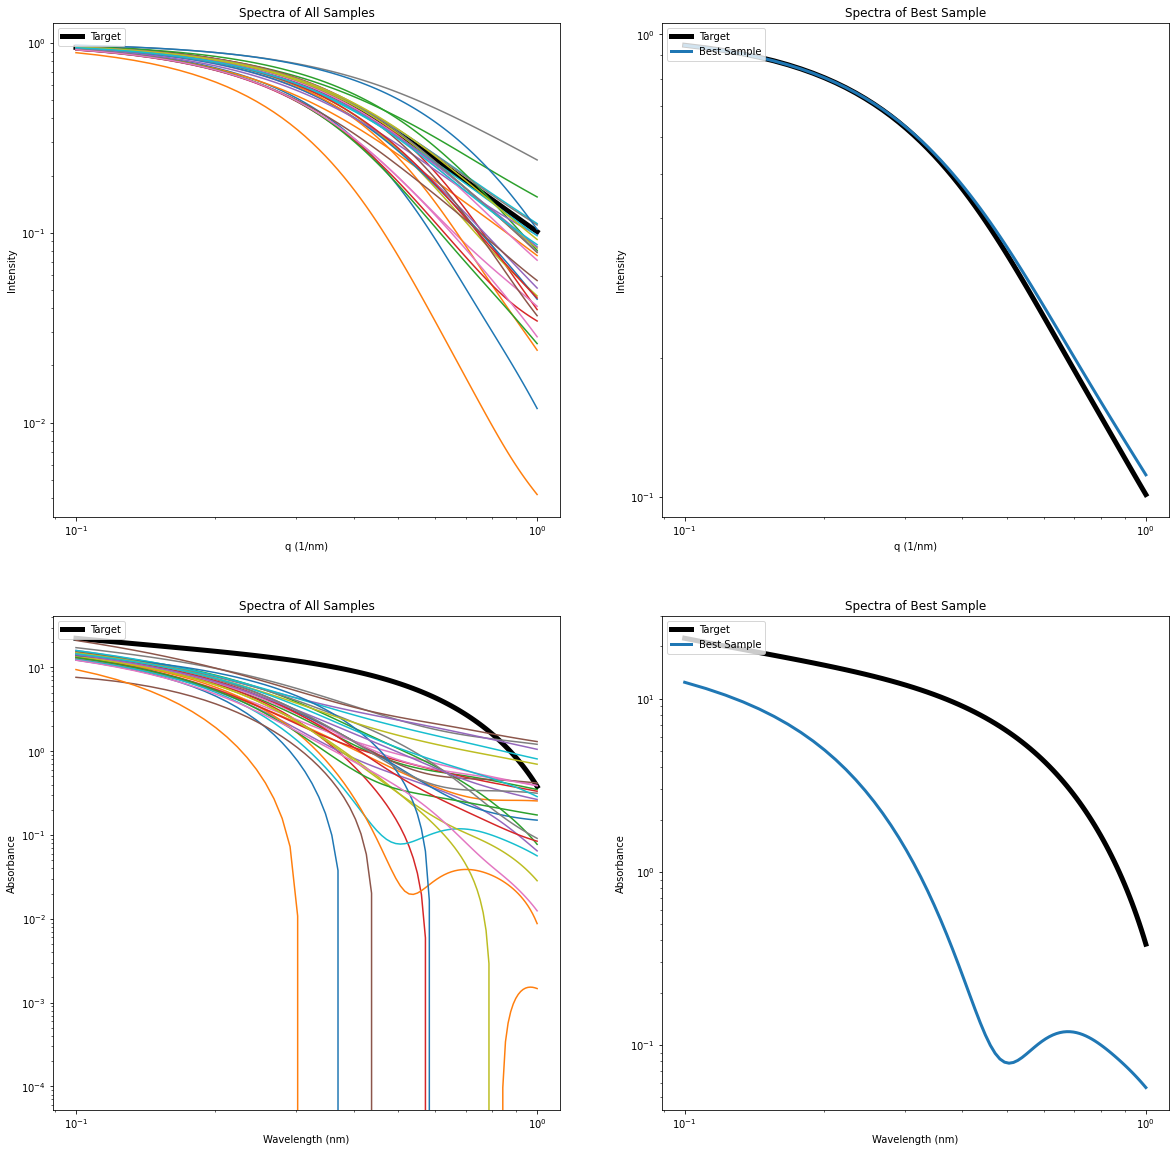

In [37]:
plot_spectra(loaded_dict, wavelength_1 = q1, wavelength_2 = q2, savefig = False)